# electrolysis cement NPV simulation

Run the electrolysis cement Monte Carlo simulation and visualize the resulting NPV distribution.

The summary also reports how many simulations have non-negative NPV (NPV >= 0) and how many have negative NPV.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_cement_results,
)

from npv_summary import summarize_metric_signs


In [2]:
TECHNOLOGY = 'electrolysis'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_cement_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_t,lifetime_years,capex_eur_per_t,fixed_opex_eur_per_t,variable_opex_eur_per_t,fuel_consumption_mwh_th_per_t,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_electricity_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_t,levelized_net_margin_eur_per_t
0,0,electrolysis,absolute,not_applicable,1000000.0,25.0,375.290817,45.758314,24.046343,0.0,...,150000000.0,4.575831e+07,2.404634e+07,0.0,6.171515e+08,6.663487e+06,-5.436196e+08,-6.178309e+09,1.067478e+07,-578.776398
1,1,electrolysis,absolute,not_applicable,1000000.0,25.0,308.778617,31.459155,22.731979,0.0,...,150000000.0,3.145916e+07,2.273198e+07,0.0,4.189488e+08,8.061427e+06,-3.312014e+08,-3.844280e+09,1.067478e+07,-360.127411
2,2,electrolysis,absolute,not_applicable,1000000.0,25.0,406.125568,36.055487,22.905368,0.0,...,150000000.0,3.605549e+07,2.290537e+07,0.0,3.993479e+08,1.082449e+07,-3.191332e+08,-3.812801e+09,1.067478e+07,-357.178579
3,3,electrolysis,absolute,not_applicable,1000000.0,25.0,353.736358,42.057214,15.948063,0.0,...,150000000.0,4.205721e+07,1.594806e+07,0.0,3.997332e+08,1.008809e+07,-3.178265e+08,-3.746463e+09,1.067478e+07,-350.964124
4,4,electrolysis,absolute,not_applicable,1000000.0,25.0,457.507210,44.478811,23.159627,0.0,...,150000000.0,4.447881e+07,2.315963e+07,0.0,3.440478e+08,5.209656e+06,-2.668959e+08,-3.306561e+09,1.067478e+07,-309.754639


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
levelized_net_margin_eur_per_t = results["levelized_net_margin_eur_per_t"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        levelized_net_margin_eur_per_t.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "Levelized net margin EUR/t cement"
        ),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,Levelized net margin EUR/t cement
count,100000.000000,100000.000000
mean,-4081.585343,-382.357932
std,1251.510994,117.240022
min,-7910.180123,-741.016016
5%,-6284.090789,-588.685953
50%,-3984.147482,-373.230072
95%,-2159.743978,-202.322179
max,-792.478612,-74.238429


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),0,0.0
1,Negative (NPV < 0),100000,1.0


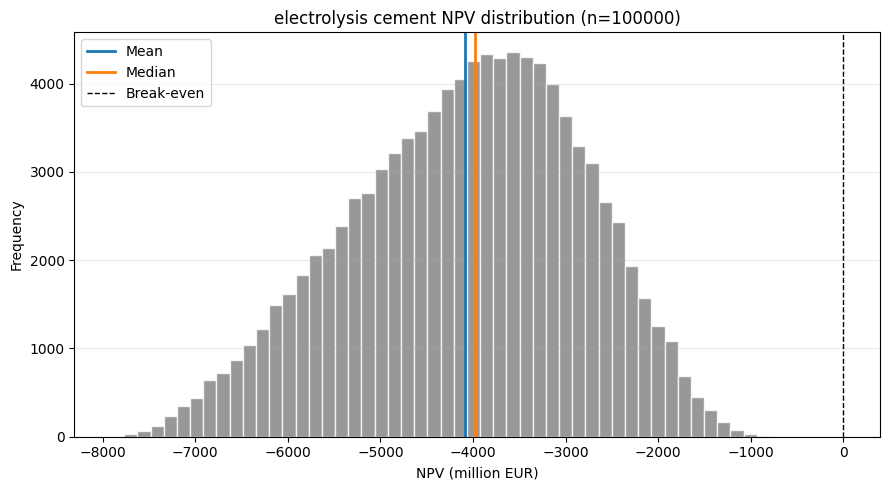

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"electrolysis cement NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


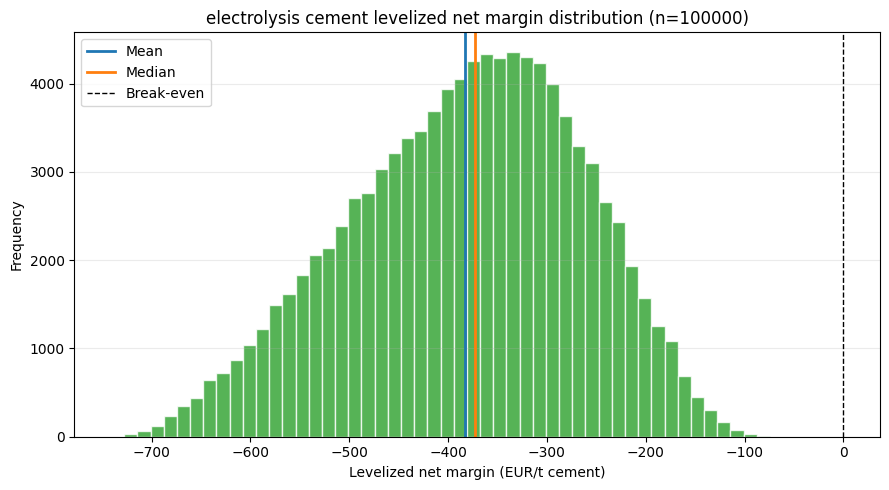

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    levelized_net_margin_eur_per_t,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    levelized_net_margin_eur_per_t.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    levelized_net_margin_eur_per_t.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"electrolysis cement levelized net margin distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("Levelized net margin (EUR/t cement)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             150.000000
annual_fixed_opex_eur           36.308136
annual_variable_opex_eur        20.006926
annual_fuel_cost_eur             0.000000
annual_electricity_cost_eur    431.747536
annual_emissions_cost_eur        8.009574
annual_net_cash_flow_eur      -346.072172
Name: Mean annual value, million EUR, dtype: float64